# Spatial Data for Economics

Graduate Quantitative Economics and Datascience

Jesse Perla (University of British Columbia)

# Overview

## Where Do Workers Live and Work?

- A workplace expansion can draw workers from neighboring counties
- @monte2018commuting show how commuting links shape local employment responses to labor-demand shocks
- Construct **commuting shares and county-pair distances**, then estimate their gravity regression
- Our example uses 2016–2020 data for eight western Washington counties

## Four Public Data Sources

| File | Observation | Source |
|:-----------------------|:-----------------------|:-----------------------|
| County boundaries | 3,234 polygons | [2020 cartographic boundaries](https://www.census.gov/geographies/mapping-files/time-series/geo/cartographic-boundary.html) |
| Population centers | 3,221 county points | [2020 mean centers](https://www.census.gov/geographies/reference-files/time-series/geo/centers-population.2020.html) |
| Commuting flows | 122,335 reported pairs | [2016–2020 ACS, Table 1](https://www.census.gov/data/tables/2020/demo/metro-micro/commuting-flows-2020.html) |
| City coordinates | 639 Washington places | [2020 Census Gazetteer](https://www.census.gov/geographies/reference-files/time-series/geo/gazetteer-files.2020.html) |

- About **14 MB** in total
- Select eight counties and five city reference points from these files

## Python Setup

- In this repository, install the optional packages with `uv sync --extra extras`
- GeoPandas adds geometry operations to pandas \[@geopandas2026\]

In [2]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

def data_path(name):
    local = Path("data") / name
    base = "https://jlperla.github.io/grad_econ_datascience/slides/data/"
    return local if local.exists() else base + name

## The Geometry Column

In [3]:
raw_counties = gpd.read_file(data_path("spatial_counties.zip"))
raw_counties[["GEOID", "NAME", "geometry"]].head(3)

- Each row has attributes and a **polygon** or **multipolygon**
- A multipolygon can contain disconnected pieces
- `GEOID` identifies the county: King County is `"53033"`
- GeoPandas reads the shapefile and its companion files from the ZIP

## Select a Region

In [4]:
county_ids = [
    "53029", "53033", "53035", "53053",
    "53057", "53061", "53067", "53073",
]
counties = raw_counties.loc[
    raw_counties.GEOID.isin(county_ids),
    ["GEOID", "NAME", "ALAND", "geometry"],
].sort_values("GEOID")

- These are Island, King, Kitsap, Pierce, Skagit, Snohomish, Thurston, and Whatcom
- `loc` selects rows and columns, keeping the geometry
- `ALAND` is the Census land area in square meters

## Plot County Boundaries

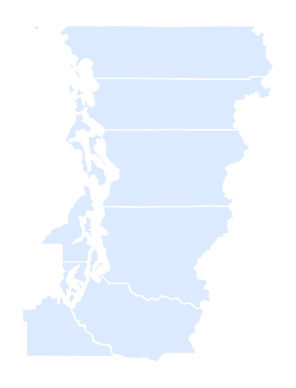

In [5]:
ax = counties.plot(
    color="#dbeafe", edgecolor="white"
)
ax.set_axis_off()
plt.show()

`plot()` draws the geometry column.

# Coordinates and Spatial Joins

## Coordinates Need Units

- A **coordinate reference system (CRS)** defines how coordinates locate points
- The source boundaries use NAD83 longitude and latitude in degrees, `EPSG:4269`
- A degree of longitude spans different distances at different latitudes
- To measure local distances, transform to a projected CRS in meters

In [6]:
print(counties.crs)

EPSG:4269

## Transform, Then Measure

In [7]:
counties_m = counties.to_crs(26910)
print(counties_m.crs.name)
print(counties_m.crs.axis_info[0].unit_name)

NAD83 / UTM zone 10N
metre

- `EPSG:26910` is NAD83 / UTM zone 10N, suitable for our western Washington sample
- `to_crs(...)` **changes the coordinate values**
- `set_crs(...)` labels existing coordinates; it does not transform them
- Choose the projection for your region ([GeoPandas guide](https://geopandas.org/en/stable/docs/user_guide/projections.html))

## Select City Coordinates

In [8]:
cities = pd.read_csv(data_path("spatial_places.csv"))
city_names = ["Bellingham city", "Everett city", "Olympia city",
             "Seattle city", "Tacoma city"]
cities = cities.loc[cities.city.isin(city_names),
                    ["city", "lon", "lat"]].copy()
cities["city"] = cities.city.str.removesuffix(" city")

Keep the five cities’ coordinates and shorten their map labels.

## From Coordinates to Points

In [9]:
points = gpd.GeoDataFrame(
    cities,
    geometry=gpd.points_from_xy(cities.lon, cities.lat),
    crs="EPSG:4269",
).to_crs(counties_m.crs)
cities.head(3)

- `x` is **longitude**, `y` is **latitude**
- These Census Gazetteer coordinates use NAD83 (`EPSG:4269`)
- They are city reference points, not workers’ home or workplace locations

## Which County Contains Each Point?

In [10]:
located = gpd.sjoin(
    points, counties_m[["GEOID", "NAME", "geometry"]],
    how="left", predicate="within",
)
located[["city", "GEOID", "NAME"]]

The **spatial join** assigns a county ID from each point’s location.

## Map the City Points

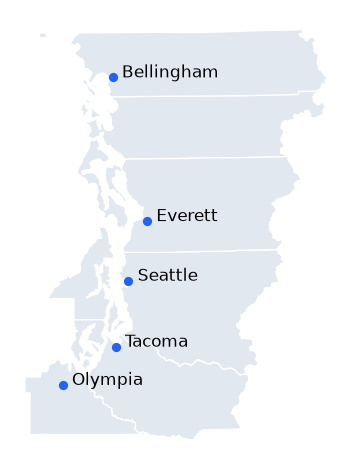

The same operation assigns establishments, schools, or transactions to areas.

## Attribute and Spatial Joins

| Operation | Matching rule | Example |
|:-----------------------|:-----------------------|:-----------------------|
| `merge` | Equal identifiers | County unemployment rate → county polygon |
| `sjoin` | A geometric relationship | Establishment coordinates → county polygon |

- Before a spatial join, put both tables in the same CRS
- A left join retains unmatched rows; inspect missing and multiple matches
- `within` excludes points exactly on a boundary
- Precise assignments near borders require more detailed boundaries

# Commuting Tables and Maps

## Load the Commuting Table

In [12]:
codes = ["home_state", "home_county", "work_state", "work_county"]
flows = pd.read_csv(
    data_path("spatial_commuting.csv.gz"), dtype=dict.fromkeys(codes, str)
)
flows[codes + ["workers"]].head(3)

- Read geographic codes as strings to preserve leading zeros
- `workers` is an ACS estimate for workers age 16+, not a count of daily trips; `moe` is its 90% margin of error

## Make County IDs Agree

In [13]:
flows["home_id"] = flows.home_state + flows.home_county
flows["work_id"] = flows.work_state.str[-2:] + flows.work_county
flows[["home_id", "work_id", "workers"]].head(3)

- A county ID joins the two-digit state code and three-digit county code
- Workplace-state codes include a country prefix; take their last two digits
- Foreign and unspecified workplaces have missing county IDs; retain these workers in home-county totals

## What Does a Flow Measure?

Let $L_{ij}$ be the reported number of workers who **live in $i$** and **work in $j$**.

$$
R_i = \sum_j L_{ij}, \qquad W_i = \sum_j L_{ji}
$$

- $R_i$: workers counted by residence; $W_i$: workers counted by workplace
- $L_{ii}$: workers who live and work in the same county, including those working from home
- Sum all reported origins and destinations, including those outside our region
- These are pooled 2016–2020 survey estimates. An absent pair is not an observed zero

## Keep Flows across the Sample Boundary

In [14]:
touches_region = flows.home_id.isin(county_ids)
touches_region |= flows.work_id.isin(county_ids)
flows = flows.loc[touches_region].copy()
residents = flows.groupby("home_id").workers.sum().rename("residents")
workplaces = flows.groupby("work_id").workers.sum().rename("workplaces")
same_county = flows.loc[flows.home_id == flows.work_id]
local = same_county.groupby("home_id").workers.sum().rename("local")

- Keep a flow when **either endpoint** is in the region: 1,155 reported pairs
- County totals include commuters entering and leaving the region

## Merge County Totals

In [15]:
county_data = counties_m.merge(
    residents, left_on="GEOID", right_index=True, how="left"
).merge(
    workplaces, left_on="GEOID", right_index=True, how="left"
).merge(
    local, left_on="GEOID", right_index=True, how="left"
)
county_data[["NAME", "residents", "workplaces"]].head(3)

Join on `GEOID`, keeping the county geometry.

## Commuting Shares

$$
\text{out-share}_i = 1 - \frac{L_{ii}}{R_i}, \qquad
\text{in-share}_i = 1 - \frac{L_{ii}}{W_i}
$$

In [16]:
county_data["out_share"] = 1 - county_data.local / county_data.residents
county_data["in_share"] = 1 - county_data.local / county_data.workplaces
county_data[["NAME", "out_share", "in_share"]].round(3).head(3)

Out-share: share of resident workers working outside the county. In-share: share of workers in the county living elsewhere.

## Map the Out-Commuting Share

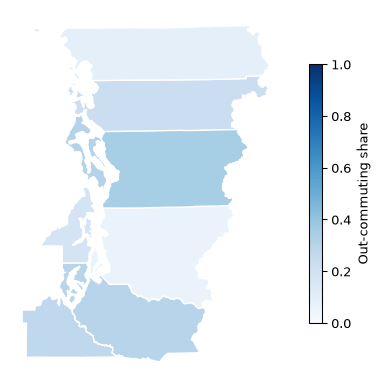

In [17]:
ax = county_data.plot(
    column="out_share", cmap="Blues",
    edgecolor="white", legend=True,
    vmin=0, vmax=1,
    legend_kwds={
        "label": "Out-commuting share",
        "shrink": 0.7,
    },
)
ax.set_axis_off()
plt.show()

Color shows the share from 0 to 1; polygon size reflects area, not worker counts.

## Why the Sample Boundary Matters

In [18]:
inside = flows.home_id.isin(counties.GEOID)
inside &= flows.work_id.isin(counties.GEOID)
internal = flows.loc[inside].copy()
retained = internal.groupby("home_id").workers.sum() / residents
retained.reindex(counties.GEOID).rename("share_kept").round(3)

GEOID
53029    0.989
53033    0.994
53035    0.981
53053    0.989
53057    0.993
53061    0.994
53067    0.942
53073    0.984
Name: share_kept, dtype: float64

Restricting both endpoints first would remove some commuters from the denominators.

# County-Pair Distances

## Match Population Centers by County ID

In [19]:
population = pd.read_csv(
    data_path("spatial_population_centers.csv"),
    dtype={"STATEFP": str, "COUNTYFP": str},
)
population["GEOID"] = population.STATEFP + population.COUNTYFP
counties = counties.merge(
    population[["GEOID", "pop_lon", "pop_lat"]], on="GEOID", how="left"
)

Join the population centers to county polygons using the five-digit `GEOID`.

## Which Center Represents a County?

In [20]:
geometric = counties_m.set_index("GEOID").geometry.centroid
centers = gpd.GeoSeries(
    gpd.points_from_xy(counties.pop_lon, counties.pop_lat),
    index=counties.GEOID, crs="EPSG:4269",
).to_crs(counties_m.crs)

- A geometric centroid weights area; a population center weights people
- Population centers approximate both endpoints; workplace locations may differ

## Attach the Two Endpoints

In [21]:
pairs = internal.loc[internal.home_id != internal.work_id].copy()
pairs["home_point"] = pairs.home_id.map(centers)
pairs["work_point"] = pairs.work_id.map(centers)

- Each row is a **directed** origin–destination pair
- Omit same-county pairs: their zero center-to-center distance does not measure travel

## Distances in Kilometers

In [22]:
origins = gpd.GeoSeries(pairs.home_point, crs=counties_m.crs)
destinations = gpd.GeoSeries(pairs.work_point, crs=counties_m.crs)
pairs["distance_km"] = origins.distance(destinations) / 1000
pairs[["home_id", "work_id", "workers", "distance_km"]].head().round(1)

`distance` measures straight-line separation for each pair, not road distance or travel time.

## Draw Connections to King County

In [23]:
from shapely.geometry import LineString

to_king = pairs.loc[pairs.work_id == "53033"].copy()
lines = gpd.GeoDataFrame(
    to_king,
    geometry=[LineString([a, b]) for a, b in
              zip(to_king.home_point, to_king.work_point)],
    crs=counties_m.crs,
)

Each **line** connects a home county’s population center to King’s.

## Commuting to King County

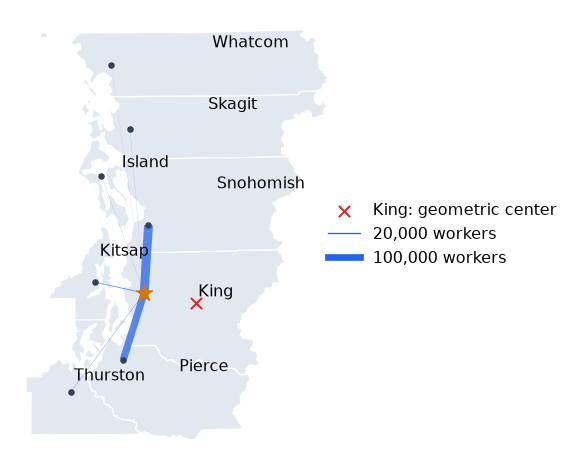

King’s geometric center (red ×) lies east of its population center (gold ★). Line widths show workers **to King**.

## Export the County Table

In [25]:
analysis = pd.DataFrame(county_data[[
    "GEOID", "NAME", "residents", "workplaces", "out_share", "in_share"
]])
output = Path("../build")
output.mkdir(exist_ok=True)
analysis.to_csv(output / "spatial_county_analysis.csv", index=False)
analysis.head(3).round(3)

- `build/spatial_county_analysis.csv` has one row per county
- `pairs` has one row per reported directed county pair

# Estimating Commuting Gravity

## The Paper’s Commuting Regression

- @monte2018commuting estimate a gravity equation in [Appendix B.6, equation (B.74)](https://www.aeaweb.org/articles/materials/9974#page=23)

$$
\log L_{ij} = \alpha_i + \delta_j + \beta \log d_{ij} + u_{ij}
$$

- $\alpha_i$: residence fixed effect; $\delta_j$: workplace fixed effect
- $\beta$: distance elasticity of commuting flows
- Dividing counts by the national total, as in the paper, only changes the intercept

## Pooled OLS

In [26]:
from math import log
import statsmodels.formula.api as smf

pairs["log_workers"] = pairs.workers.map(log)
pairs["log_distance"] = pairs.distance_km.map(log)
pooled = smf.ols("log_workers ~ log_distance", data=pairs).fit()

- The 53 pairs have positive flows and distances; each receives equal weight
- The pooled slope mixes distance with county size and attractiveness

## Residence and Workplace Fixed Effects

In [27]:
fixed_effects = "C(home_id) + C(work_id)"
gravity = smf.ols(
    "log_workers ~ log_distance + " + fixed_effects, data=pairs
).fit()

- `C(...)` adds county indicators, omitting reference categories
- Residence effects absorb origin factors such as the number of resident workers
- Workplace effects absorb destination factors such as employment size

## Compare the Estimates

In [28]:
results = pd.DataFrame({
    "Pooled OLS": [pooled.params.log_distance,
                   pooled.rsquared, pooled.nobs],
    "Residence + workplace FE": [gravity.params.log_distance,
                                 gravity.rsquared, gravity.nobs],
}, index=["Distance elasticity", "R-squared", "Pairs"])
results.round(3)

- The distance relationship is steeper after adding county effects
- $R^2$ measures in-sample fit; the fixed-effects model also uses more parameters

## Remove County Effects

In [29]:
flow_resid = smf.ols(
    "log_workers ~ " + fixed_effects, data=pairs
).fit().resid
distance_resid = smf.ols(
    "log_distance ~ " + fixed_effects, data=pairs
).fit().resid

- Regress each variable on the same residence and workplace effects
- Plot the residuals against each other
- Their fitted slope equals the full regression’s distance coefficient (Frisch–Waugh–Lovell)

## Commuting Gravity

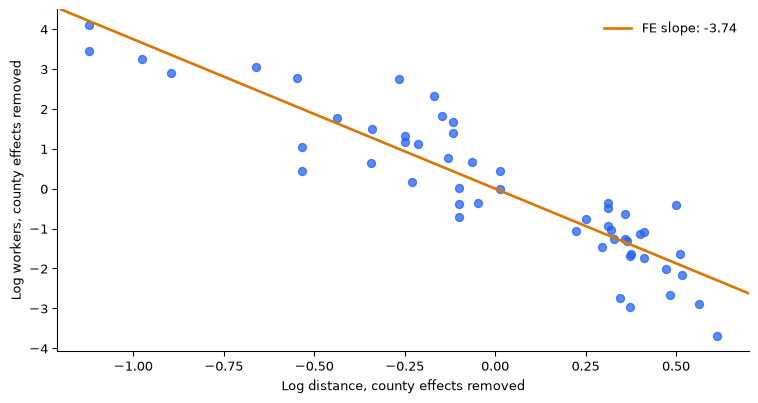

The same residual plot as [Figure B.5](https://www.aeaweb.org/articles/materials/9974#page=24), using our sample and population-center distances.

## Interpret the Distance Elasticity

Holding county effects fixed, doubling distance multiplies the fitted flow by $2^{\hat\beta}$.

In [31]:
beta = gravity.params.log_distance
print(f"Distance elasticity: {beta:.2f}")
print(f"Fitted change when distance doubles: {100 * (2**beta - 1):.1f}%")

Distance elasticity: -3.74
Fitted change when distance doubles: -92.5%

- Commuting falls sharply with distance, conditional on county effects
- The paper estimates $-4.43$ with national 2006–2010 data, centroid distances, and adjusted flows
- This association does not identify employment responses to plant openings; the paper studies those separately

## References